In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import scipy.io
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sb
import gc

# sc.settings.verbosity = 3
# sc.logging.print_versions()

### Analyze data

In [2]:
adata = sc.read('/local/home/am/EX_M/datasets/scRNA/skin/skin_preprocessed.h5ad')
adata

AnnData object with n_obs × n_vars = 15457 × 20349
    obs: 'age', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'donor_id', 'suspension_type', 'Cluster', 'Celltype', 'tissue_type', 'sample_id', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'alignment_software', 'manner_of_death', 'sample_source', 'sample_collection_method', 'institute', 'sampled_site_condition', 'sample_preservation_method', 'sequenced_fragment', 'reference_genome', 'cell_enrichment', 'gene_annotation_version', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'citation', 'log1p', 'organism', 'organism_

In [3]:
adata.var

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,n_cells
ENSG00000238009,False,ENSG00000238009,NCBITaxon:9606,gene,629,lncRNA,23
ENSG00000228463,False,ENSG00000228463,NCBITaxon:9606,gene,1902,transcribed_processed_pseudogene,931
ENSG00000237094,False,ENSG00000237094,NCBITaxon:9606,gene,183,transcribed_unprocessed_pseudogene,37
ENSG00000228327,False,ENSG00000228327,NCBITaxon:9606,gene,417,transcribed_unprocessed_pseudogene,57
ENSG00000237491,False,LINC01409,NCBITaxon:9606,gene,1059,lncRNA,84
...,...,...,...,...,...,...,...
ENSG00000212907,False,MT-ND4L,NCBITaxon:9606,gene,297,protein_coding,5323
ENSG00000198886,False,MT-ND4,NCBITaxon:9606,gene,1378,protein_coding,14548
ENSG00000198786,False,MT-ND5,NCBITaxon:9606,gene,1812,protein_coding,9327
ENSG00000198695,False,MT-ND6,NCBITaxon:9606,gene,525,protein_coding,744


/local/home/am/miniconda3/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/local/home/am/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


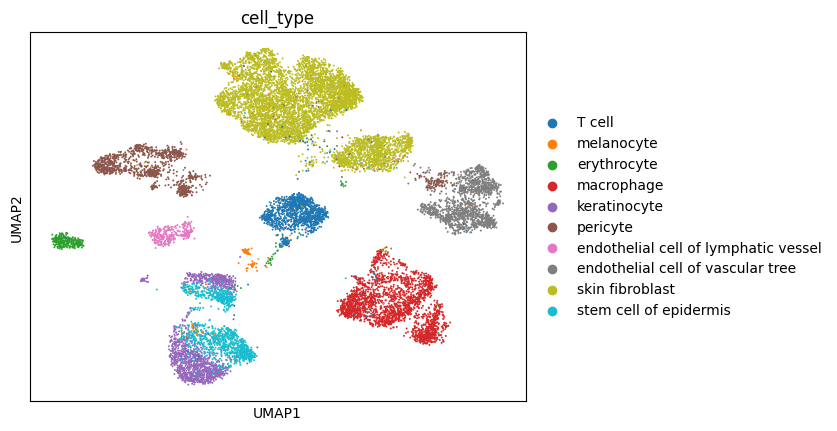

In [4]:
sc.pp.highly_variable_genes(adata, n_top_genes=4000)
sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type'], ncols=2)

In [2]:
train = sc.read('/local/home/am/EX_M/datasets/scRNA/skin/seed_32/scFoundation/train/skin_train_processed.h5ad')
train

AnnData object with n_obs × n_vars = 12154 × 19264
    obs: 'age', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'donor_id', 'suspension_type', 'Cluster', 'Celltype', 'tissue_type', 'sample_id', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'alignment_software', 'manner_of_death', 'sample_source', 'sample_collection_method', 'institute', 'sampled_site_condition', 'sample_preservation_method', 'sequenced_fragment', 'reference_genome', 'cell_enrichment', 'gene_annotation_version', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'study_pi', 'title'

In [14]:
# find ratio of non-zero entries in train.X
(train.X > 0).sum() / (train.X.shape[0] * train.X.shape[1])

0.06365301688493852

In [3]:
print(((train.X > 0).sum(axis=1) >= 7000).sum())

train = train[train.obs[(train.X > 0).sum(axis=1) < 7000].index]
train

1


View of AnnData object with n_obs × n_vars = 12153 × 19264
    obs: 'age', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'donor_id', 'suspension_type', 'Cluster', 'Celltype', 'tissue_type', 'sample_id', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'alignment_software', 'manner_of_death', 'sample_source', 'sample_collection_method', 'institute', 'sampled_site_condition', 'sample_preservation_method', 'sequenced_fragment', 'reference_genome', 'cell_enrichment', 'gene_annotation_version', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'study_pi', 'ti

In [4]:
# save the train data
train.write('/local/home/am/EX_M/datasets/scRNA/skin/seed_32/scFoundation/train/skin_train_processed.h5ad')

In [5]:
test = sc.read('/local/home/am/EX_M/datasets/scRNA/skin/seed_32/scFoundation/test/skin_test_processed.h5ad')
test

AnnData object with n_obs × n_vars = 1520 × 19264
    obs: 'age', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'donor_id', 'suspension_type', 'Cluster', 'Celltype', 'tissue_type', 'sample_id', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'alignment_software', 'manner_of_death', 'sample_source', 'sample_collection_method', 'institute', 'sampled_site_condition', 'sample_preservation_method', 'sequenced_fragment', 'reference_genome', 'cell_enrichment', 'gene_annotation_version', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'study_pi', 'title'

In [6]:
print(((test.X > 0).sum(axis=1) >= 7000).sum())

test = test[test.obs[(test.X > 0).sum(axis=1) < 7000].index]
test

0


View of AnnData object with n_obs × n_vars = 1520 × 19264
    obs: 'age', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'donor_id', 'suspension_type', 'Cluster', 'Celltype', 'tissue_type', 'sample_id', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'alignment_software', 'manner_of_death', 'sample_source', 'sample_collection_method', 'institute', 'sampled_site_condition', 'sample_preservation_method', 'sequenced_fragment', 'reference_genome', 'cell_enrichment', 'gene_annotation_version', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'study_pi', 'tit

In [7]:
# save the test data

test.write('/local/home/am/EX_M/datasets/scRNA/skin/seed_32/scFoundation/test/skin_test_processed.h5ad')

In [8]:
val = sc.read('/local/home/am/EX_M/datasets/scRNA/skin/seed_32/scFoundation/validation/skin_val_processed.h5ad')
val

AnnData object with n_obs × n_vars = 1519 × 19264
    obs: 'age', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'donor_id', 'suspension_type', 'Cluster', 'Celltype', 'tissue_type', 'sample_id', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'alignment_software', 'manner_of_death', 'sample_source', 'sample_collection_method', 'institute', 'sampled_site_condition', 'sample_preservation_method', 'sequenced_fragment', 'reference_genome', 'cell_enrichment', 'gene_annotation_version', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'study_pi', 'title'

In [9]:
val = val[val.obs[(val.X > 0).sum(axis=1) < 7000].index]

In [10]:
# save the val data

val.write('/local/home/am/EX_M/datasets/scRNA/skin/seed_32/scFoundation/validation/skin_val_processed.h5ad')

In [11]:
train.obs['celltype'].value_counts()

celltype
skin fibroblast                         4759
macrophage                              1782
endothelial cell of vascular tree       1174
keratinocyte                            1118
T cell                                  1025
pericyte                                 976
stem cell of epidermis                   950
endothelial cell of lymphatic vessel     235
melanocyte                                98
erythrocyte                               36
Name: count, dtype: int64

In [12]:
test.obs['celltype'].value_counts()

celltype
skin fibroblast                         595
macrophage                              223
endothelial cell of vascular tree       147
keratinocyte                            140
T cell                                  128
pericyte                                122
stem cell of epidermis                  119
endothelial cell of lymphatic vessel     29
melanocyte                               12
erythrocyte                               5
Name: count, dtype: int64

In [13]:
val.obs['celltype'].value_counts()

celltype
skin fibroblast                         594
macrophage                              223
endothelial cell of vascular tree       146
keratinocyte                            140
T cell                                  128
pericyte                                122
stem cell of epidermis                  118
endothelial cell of lymphatic vessel     30
melanocyte                               13
erythrocyte                               5
Name: count, dtype: int64